In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_curve, auc

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [5]:
df = pd.read_csv("default_credit_card_clients.csv")
df = df.drop("Unnamed: 0", axis=1)
df = df.drop(0)
df['Y'] = df['Y'].astype(int)
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
1,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
2,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [6]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 1 to 30000
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   X1      30000 non-null  object
 1   X2      30000 non-null  object
 2   X3      30000 non-null  object
 3   X4      30000 non-null  object
 4   X5      30000 non-null  object
 5   X6      30000 non-null  object
 6   X7      30000 non-null  object
 7   X8      30000 non-null  object
 8   X9      30000 non-null  object
 9   X10     30000 non-null  object
 10  X11     30000 non-null  object
 11  X12     30000 non-null  object
 12  X13     30000 non-null  object
 13  X14     30000 non-null  object
 14  X15     30000 non-null  object
 15  X16     30000 non-null  object
 16  X17     30000 non-null  object
 17  X18     30000 non-null  object
 18  X19     30000 non-null  object
 19  X20     30000 non-null  object
 20  X21     30000 non-null  object
 21  X22     30000 non-null  object
 22  X23     30000 non-null

,Y
count,30000.000000
mean,0.221200
std,0.415062
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [7]:
df.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
       'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21',
       'X22', 'X23', 'Y'],
      dtype='object')

In [8]:
df.isnull().sum()

X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
X11    0
X12    0
X13    0
X14    0
X15    0
X16    0
X17    0
X18    0
X19    0
X20    0
X21    0
X22    0
X23    0
Y      0
dtype: int64

In [9]:
df['Y'].value_counts()

Y
0    23364
1     6636
Name: count, dtype: int64

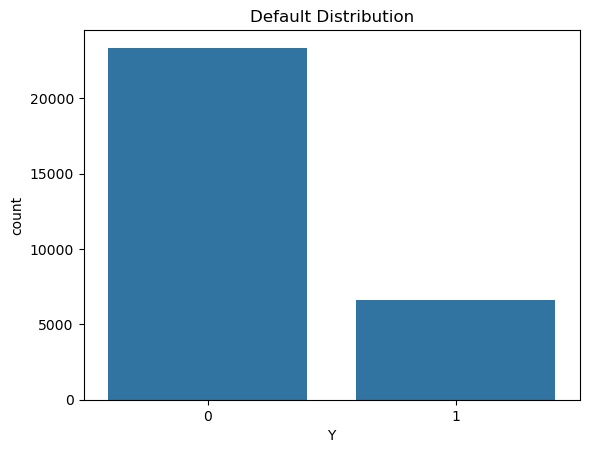

In [10]:
sns.countplot(x='Y', data=df)
plt.title("Default Distribution")
plt.show()

In [11]:
X = df.drop('Y', axis=1)
y = df['Y']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

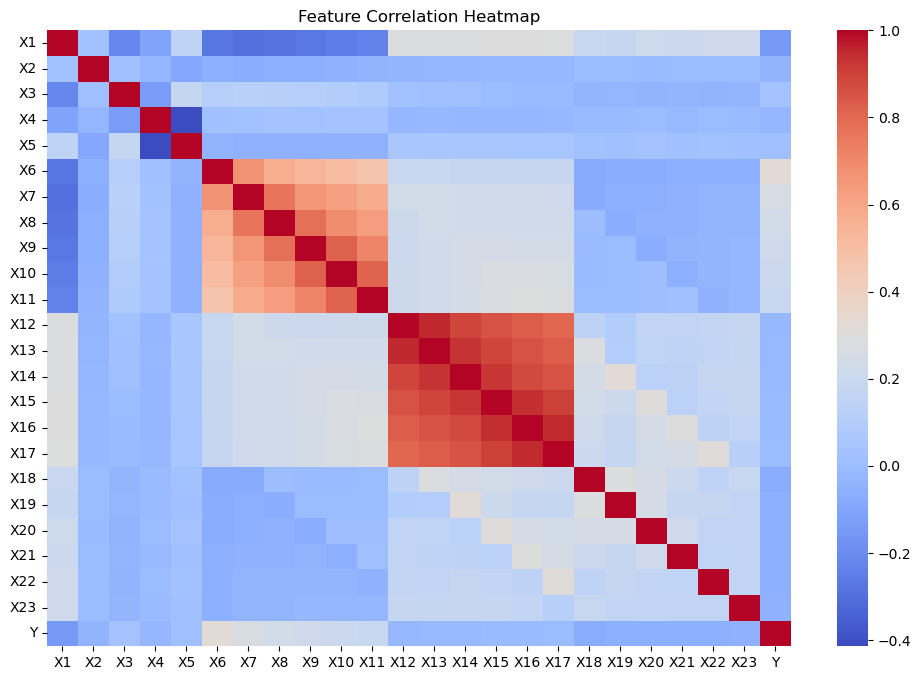

In [13]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

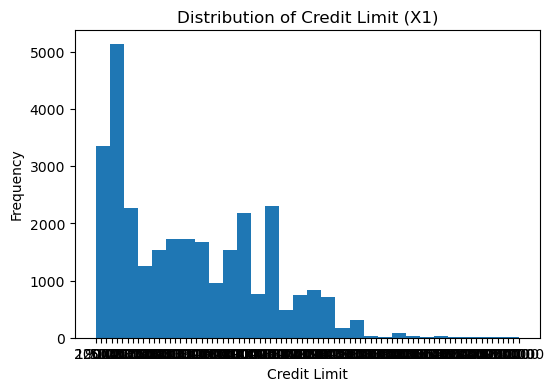

In [14]:
plt.figure(figsize=(6,4))
plt.hist(df['X1'], bins=30)
plt.title("Distribution of Credit Limit (X1)")
plt.xlabel("Credit Limit")
plt.ylabel("Frequency")
plt.show()

In [14]:
lda = LinearDiscriminantAnalysis()

lda.fit(X_train, y_train)

y_pred_lda = lda.predict(X_test)

In [15]:
cm = confusion_matrix(y_test, y_pred_lda)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[4529  158]
 [ 988  325]]


In [16]:
accuracy = accuracy_score(y_test, y_pred_lda)

print("Accuracy:", accuracy)

Accuracy: 0.809


In [17]:
print(classification_report(y_test, y_pred_lda))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4687
           1       0.67      0.25      0.36      1313

    accuracy                           0.81      6000
   macro avg       0.75      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000



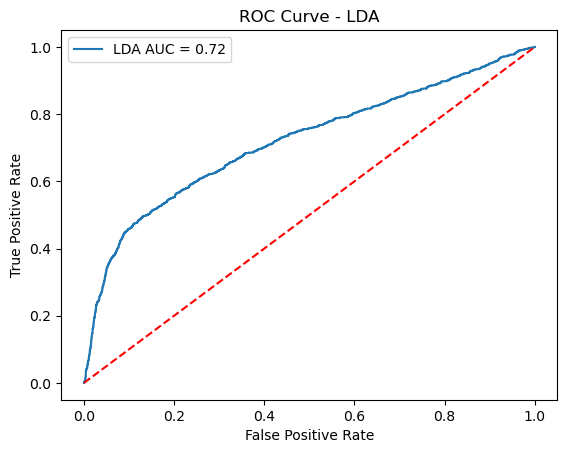

In [18]:
y_prob = lda.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

import matplotlib.pyplot as plt

plt.plot(fpr, tpr, label="LDA AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - LDA")
plt.legend()
plt.show()

In [19]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [20]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Confusion Matrix:")
print(cm_lr)

Confusion Matrix:
[[4549  138]
 [1004  309]]


In [21]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", accuracy_lr)

Accuracy: 0.8096666666666666


In [22]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4687
           1       0.69      0.24      0.35      1313

    accuracy                           0.81      6000
   macro avg       0.76      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000



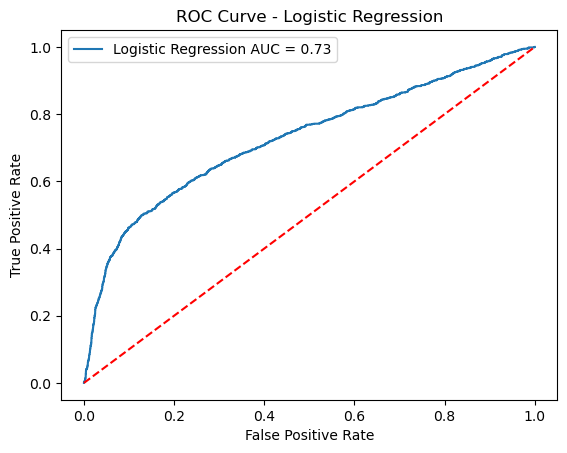

In [23]:
y_prob_lr = lr.predict_proba(X_test)[:,1]

fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_prob_lr)

roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression AUC = %0.2f" % roc_auc_lr)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [26]:
svm = SVC(kernel='rbf', probability=True)

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("Prediction completed")

Prediction completed


In [27]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

print("Confusion Matrix:")
print(cm_svm)

Confusion Matrix:
[[4482  205]
 [ 877  436]]


In [28]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("Accuracy:", accuracy_svm)

Accuracy: 0.8196666666666667


In [29]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.84      0.96      0.89      4687
           1       0.68      0.33      0.45      1313

    accuracy                           0.82      6000
   macro avg       0.76      0.64      0.67      6000
weighted avg       0.80      0.82      0.79      6000



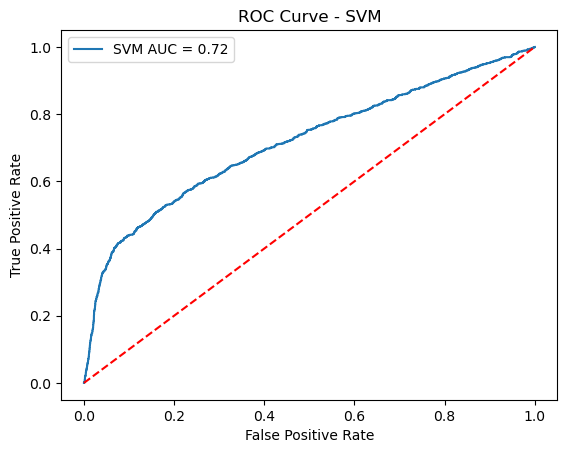

In [30]:
y_prob_svm = svm.predict_proba(X_test)[:,1]

fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_prob_svm)

roc_auc_svm = auc(fpr_svm, tpr_svm)

plt.plot(fpr_svm, tpr_svm, label="SVM AUC = %0.2f" % roc_auc_svm)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.show()

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest model trained")

Random Forest model trained


In [25]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:")
print(cm_rf)

Confusion Matrix:
[[4415  272]
 [ 831  482]]


In [26]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy:", accuracy_rf)

Accuracy: 0.8161666666666667


In [27]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4687
           1       0.64      0.37      0.47      1313

    accuracy                           0.82      6000
   macro avg       0.74      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000



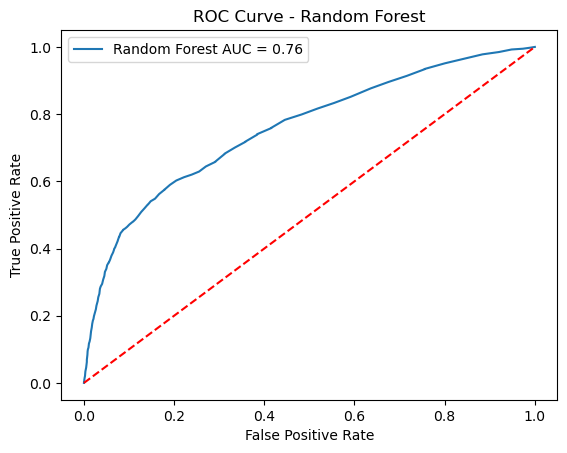

In [28]:
y_prob_rf = rf.predict_proba(X_test)[:,1]

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)

roc_auc_rf = auc(fpr_rf, tpr_rf)

import matplotlib.pyplot as plt

plt.plot(fpr_rf, tpr_rf, label="Random Forest AUC = %0.2f" % roc_auc_rf)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

In [2]:
!pip install xgboost

In [15]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='logloss')

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost model trained")

XGBoost model trained


In [16]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print("Confusion Matrix:")
print(cm_xgb)

Confusion Matrix:
[[4413  274]
 [ 837  476]]


In [17]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)

print("Accuracy:", accuracy_xgb)

Accuracy: 0.8148333333333333


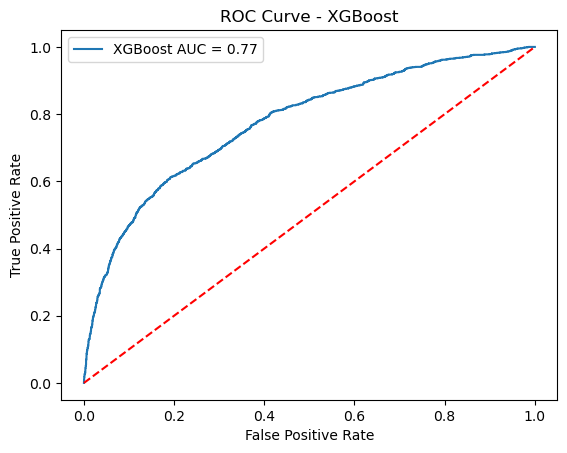

In [18]:
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_prob_xgb)

roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.plot(fpr_xgb, tpr_xgb, label="XGBoost AUC = %0.2f" % roc_auc_xgb)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()

In [1]:
!pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/351.2 MB 3.4 MB/s eta 0:01:44
   ---------------------------------------- 0.5/351.2 MB 3.4 MB/s eta 0:01:44
   ---------------------------------------- 0.8/351.2 MB 1.1 MB/s eta 0:05:08
   ---------------------------------------- 1.0/351.2 MB 1.5 MB/s eta 0:03:52
   ---------------------------------------- 1.6/351.2 MB 1.5 MB/s eta 0:03:59
   ---------------------------------------- 1.6/351.2 MB 1.5 MB/s eta 0:03:59
   ---------------------------------------- 2.1/351.2 MB 1.4 MB/s eta 0:04:04
   ---------------------------------------- 2.4/351.2 MB 1.5 MB/s eta 0:03:50
   ---------------------------------------- 2.4/351.2 MB 1.5 MB/s eta 0:03:50
   ---------------------------------------- 2.9/351.2 MB 1.4 MB/s eta 0:04:05
   ---------------------------------------- 3.1/351.2 MB 1.5 MB/s eta 0:04:00
   ---------------------------------------- 3.4/351.2 MB 1.3 MB/s eta 0

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.0 which is incompatible.


In [2]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [18]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8029 - loss: 0.4860
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8135 - loss: 0.4532
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8172 - loss: 0.4456
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8186 - loss: 0.4418
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8198 - loss: 0.4383
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8198 - loss: 0.4362
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8205 - loss: 0.4338
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8204 - loss: 0.4323
Epoch 9/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8202 - loss: 0.4311
Epoch 10/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8199 - loss: 0.4298
Epoch 11/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8198 - loss: 0.4287
Epoch 12/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

In [19]:
y_prob_dnn = model.predict(X_test)

y_pred_dnn = (y_prob_dnn > 0.5)

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [20]:
cm_dnn = confusion_matrix(y_test, y_pred_dnn)

print("Confusion Matrix:")
print(cm_dnn)

Confusion Matrix:
[[4412  275]
 [ 808  505]]


In [21]:
accuracy_dnn = accuracy_score(y_test, y_pred_dnn)

print("Accuracy:", accuracy_dnn)

Accuracy: 0.8195


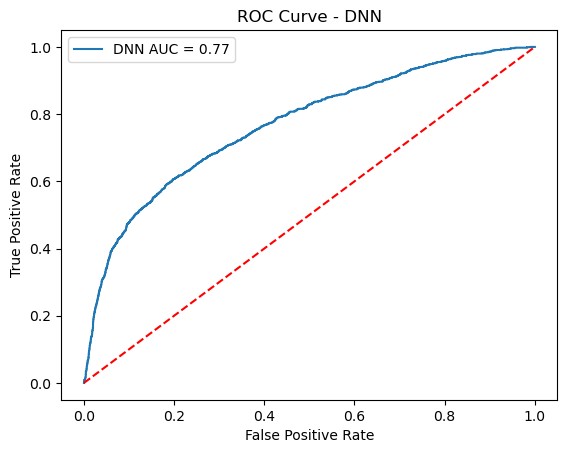

In [22]:
fpr_dnn, tpr_dnn, thresholds_dnn = roc_curve(y_test, y_prob_dnn)

roc_auc_dnn = auc(fpr_dnn, tpr_dnn)

import matplotlib.pyplot as plt

plt.plot(fpr_dnn, tpr_dnn, label="DNN AUC = %0.2f" % roc_auc_dnn)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - DNN")
plt.legend()
plt.show()